<a href="https://colab.research.google.com/github/luky048-ship-it/Data_Analysis/blob/main/%D0%97%D0%B0%D0%B4%D0%B0%D0%BD%D0%B8%D0%B55_15_04_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Практическое задание №5

Используйте данные из файла **burnout.xlsx** с информацией об академических работниках.

В нём содержатся следующие переменные:


| Название переменной | Описание переменной
|:-------------------:|:------------------:|
| burnout | выгорание на работе |
| loc | ощущаемый контроль (чем больше значение, тем меньше ощущение контроля над ситуацией) |
| cope | способность справляться со сложностями (чем больше значение, тем меньше способность)|
| teaching | стресс от преподавания (чем выше значение, тем выше уровень стресса)|
| research | стресс от проведения исследований (чем выше значение, тем выше уровень стресса)|
| pastoral | стресс от бескорыстной помощи коллегам и студентам (чем выше значение, тем выше уровень стресса)|
| gender | пол (мужской, женский)|
| degree | наличие учёной степени (phd – кандидат наук), mba (мастер делового администрирования), ms (магистр)|

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score, roc_curve
from sklearn.model_selection import train_test_split
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import cross_val_score, KFold
from scipy.stats import pointbiserialr
import statsmodels.api as sm
import warnings
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_excel('/content/drive/MyDrive/Colab Notebooks/Homeworc5/burnout.xlsx')

display(df.head())
print(df.info())
print(df.describe())
print("\n")
print(df.isnull().sum())

,burnout,loc,cope,teaching,research,pastoral,gender,degree
0,Burnt Out,61.764706,81.679389,94.545455,81.250000,96.296296,male,mba
1,Burnt Out,42.941176,39.694656,94.545455,60.416667,87.037037,male,mba
2,Burnt Out,22.352941,17.557252,63.636364,64.583333,68.518519,male,mba
3,Burnt Out,13.529412,25.190840,60.000000,62.500000,66.666667,male,mba
4,Burnt Out,38.235294,34.351145,61.818182,68.750000,61.111111,male,mba


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 467 entries, 0 to 466
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   burnout   467 non-null    object 
 1   loc       467 non-null    float64
 2   cope      467 non-null    float64
 3   teaching  467 non-null    float64
 4   research  467 non-null    float64
 5   pastoral  467 non-null    float64
 6   gender    467 non-null    object 
 7   degree    467 non-null    object 
dtypes: float64(5), object(3)
memory usage: 29.3+ KB
None
              loc        cope    teaching    research    pastoral
count  467.000000  467.000000  467.000000  467.000000  467.000000
mean    17.900239   23.919120   55.425346   61.906674   55.246253
std     11.928564   15.720822   12.819639   14.738699   13.475945
min      6.470588    3.816794   16.363636   20.833333   18.518519
25%      9.411765   12.213740   47.272727   52.083333   46.296296
50%     14.117647   19.083969   54.545455   62.50000

Метрические переменные измерены по шкале от 0 до 100.

Выполните, пожалуйста, следующие задания.

1. Сформулируйте гипотезы, которые будут проверены в ходе исследования.

На основании переменной `burnout` выдвинем ряд гипотез, подходящих для исследования данного датасета и логистической регрессии.
# Предполагаемые гипотезы:
    1) Влияет ли специфика академической работы (преподавание, наука, помощь коллегам) на риск выгорания?
        * Гипотеза (H1): Рост нагрузки в любой из этих сфер увеличивает вероятность попадания сотрудника в категорию "выгорание".
    2) Насколько сильно внутреннее состояние человека и его умение справляться с трудностями защищают от выгорания?
        * Гипотеза (H1): Чем меньше человек чувствует контроль над ситуацией (`loc`) и чем хуже он справляется со сложностями (`cope`), тем  выше риск выгорания.
    3) Есть ли группы риска среди сотрудников разного пола или с разным уровнем образования?
        * Гипотеза (H1): Вероятность выгорания зависит от пола и наличия учёной степени.

# Целевая переменная

<Axes: xlabel='burnout', ylabel='count'>

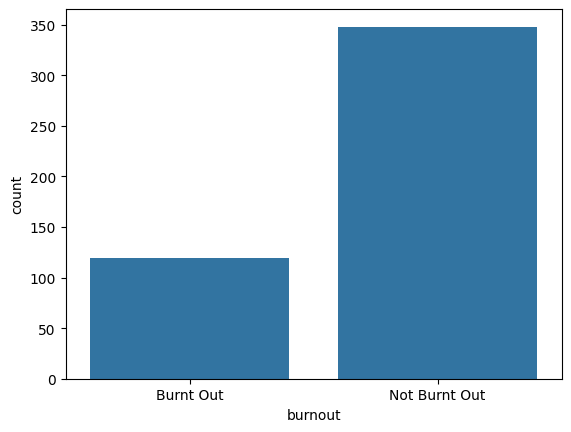

In [4]:
sns.countplot(data=df, x='burnout')


# Значения по группам целевой переменной

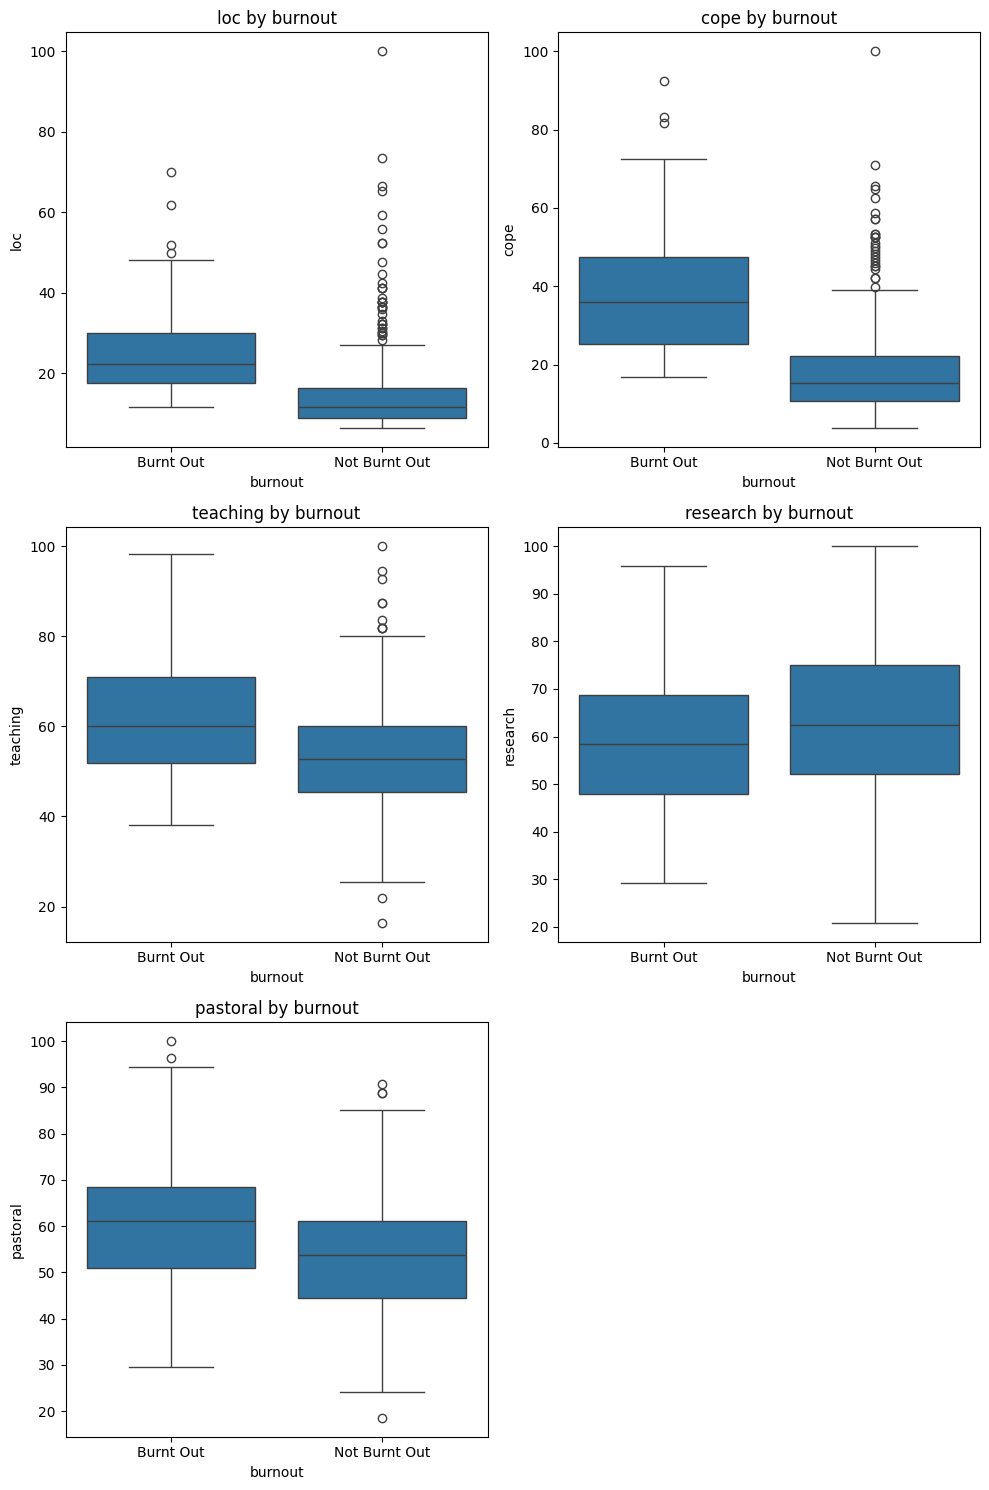

In [5]:
numerical_features = ['loc', 'cope', 'teaching', 'research', 'pastoral']

plt.figure(figsize=(10,15))

for i, col in enumerate(numerical_features, 1):
    plt.subplot(3, 2, i)
    sns.boxplot(x='burnout', y=col, data=df)
    plt.title(f'{col} by burnout')

plt.tight_layout()
plt.show()

In [6]:
df['burnout'] = df['burnout'].map({'Burnt Out': 1, 'Not Burnt Out': 0})
target = 'burnout'

for col in numerical_features:
    corr, p_value = pointbiserialr(df[col], df[target])
    print(f"{col}: корреляция = {corr:.3f}, p-value = {p_value:.5f}")

loc: корреляция = 0.363, p-value = 0.00000
cope: корреляция = 0.534, p-value = 0.00000
teaching: корреляция = 0.277, p-value = 0.00000
research: корреляция = -0.116, p-value = 0.01198
pastoral: корреляция = 0.224, p-value = 0.00000


In [7]:
print("Категориальные признаки в процентном соотношении\n")
display(pd.crosstab(df['gender'], df['burnout'], normalize='index') * 100)
print("\n")
display(pd.crosstab(df['degree'], df['burnout'], normalize='index') * 100)


Категориальные признаки в процентном соотношении



burnout,0,1
gender,,
female,72.649573,27.350427
male,76.394850,23.605150


burnout,0,1
degree,,
mba,73.611111,26.388889
ms,72.941176,27.058824
phd,75.161290,24.838710


# Предварительный анализ
На основании полученных данных, мы можем сделать предварительные выводы. Переменные, связанные с внутренним состоянием сотрудника `loc`, `cope` демонстрируют наиболее выраженные различия между группами. Что позволяет дать предварительную оценку о том, что они являются ключевыми предикторами выгорания.

К предикторам с более умеренным влиянием можно отнести `teaching`,`research`,`pastoral` - по всем трём видам академической нагрузки у группы “Burnt Out” медианные значения выше:

- больше преподавания
- больше научной нагрузки
- больше поддержки коллег

Переменные, связанные с рабочей нагрузкой, демонстрируют разные тенденции. `teaching` и `pastoral` выше у сотрудников с выгоранием, что согласуется с гипотезой о негативном влиянии нагрузки. Однако `research` имеет более высокие значения у сотрудников без выгорания, что может указывать на меньшую стрессовость исследовательской деятельности или на влияние компенсирующего признака в виде более интересной и неоднообразной работы.

Самые слабые различия идут по полу и уровню образования. Разница ~5% не даёт оснований считать эти переменные значимыми факторами риска.

2. Постройте модель бинарной логистической регрессии. Зависимая переменная – burnout. В качестве предикторов используйте все остальные переменные. Напишите уравнение регрессии (линейная часть). Охарактеризуйте регрессионную модель. Оцените статистическую значимость и предсказательную силу модели. Постройте ROC-кривую и прокомментируйте её. Рассчитайте площадь под ROC-кривой.

In [8]:
y_train = df['burnout']
X_train = df[numerical_features]

X_const = sm.add_constant(X_train)

vif = pd.DataFrame()
vif["feature"] = X_const.columns
vif["VIF"] = [variance_inflation_factor(X_const.values, i) for i in range(X_const.shape[1])]
print(vif, "\n")


model = sm.Logit(y_train, X_const).fit()
print(model.summary())


    feature        VIF
0     const  52.692174
1       loc   1.256606
2      cope   1.788560
3  teaching   2.290756
4  research   1.080846
5  pastoral   1.365288 

Optimization terminated successfully.
         Current function value: 0.343896
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:                burnout   No. Observations:                  467
Model:                          Logit   Df Residuals:                      461
Method:                           MLE   Df Model:                            5
Date:                Sat, 18 Apr 2026   Pseudo R-squ.:                  0.3941
Time:                        09:36:26   Log-Likelihood:                -160.60
converged:                       True   LL-Null:                       -265.05
Covariance Type:            nonrobust   LLR p-value:                 3.524e-43
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------

In [9]:
# model — результат fit() из statsmodels Logit
params = model.params
bse = model.bse
pvalues = model.pvalues

# OR и 95% CI
or_vals = np.exp(params)
ci_lower = np.exp(params - 1.96 * bse)
ci_upper = np.exp(params + 1.96 * bse)

summary_df = pd.DataFrame({
    'coef': params,
    'OR': or_vals,
    'CI 2.5%': ci_lower,
    'CI 97.5%': ci_upper,
    'std err': bse,
    'p-value': pvalues
})

# Округление для отчёта
summary_df = summary_df.round(3)
print(summary_df)

           coef     OR  CI 2.5%  CI 97.5%  std err  p-value
const    -4.440  0.012    0.001     0.099    1.086    0.000
loc       0.111  1.117    1.085     1.150    0.015    0.000
cope      0.142  1.153    1.117     1.191    0.016    0.000
teaching -0.112  0.894    0.860     0.929    0.020    0.000
research  0.019  1.019    0.999     1.040    0.010    0.062
pastoral  0.045  1.046    1.020     1.073    0.013    0.001


# Вывод

VIF - находится в допустимых значениях, в данной выборке нет мультиколлинеарности.

**Уравнение регрессии (линейная часть):** n = -4.4399 + (0.1108 ⋅ loc) + (0.1423 ⋅ cope) - (0.1122 ⋅ teaching) + (0.0193 ⋅ research) + (0.0452 ⋅ pastoral)

Значение Pseudo R² = 0.394 указывает на то, что включённые в модель предикторы объясняют около 40% вариации выгорания. Это указывает на то, что модель успешно выявляет значимую часть факторов, связанных с выгоранием, однако значительная доля вариации остаётся необъяснённой. Это связано не с недостатком наблюдений или статистическими проблемами модели, а с неполнотой набора переменных: выгорание является многопричинным явлением, и в данных отсутствуют важные организационные, личностные и социальные факторы.

Все ключевые переменные, кроме исследовательского стресса, оказались статистически значимыми. Уменьшение контроля над ситуацией (loc) и снижение способности справляться со стрессом (cope) существенно увеличивают вероятность выгорания. Административная нагрузка (pastoral) также повышает риск. Интересно, что стресс от преподавания (teaching) связан с более низкой вероятностью выгорания, что может отражать защитный эффект структурированной преподавательской деятельности. Модель статистически значима в целом (LLR p < 0.001) и демонстрирует хорошую сходимость.

При построении ML-модели мы исключим предиктор `research`, поскольку она не улучшает предсказательную способность и добавляет шум.

In [10]:
y_train = df['burnout']
numerical_features = ['loc', 'cope', 'teaching', 'pastoral']
X_train = df[numerical_features]

X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42
)

modelML = LogisticRegression()
modelML.fit(X_train, y_train)

LogisticRegression()

In [12]:
y_train_pred = modelML.predict(X_train)

Метрики на обучающей выборке

Точность: 0.8230563002680965 

Матрица ошибок:
[[260  22]
 [ 44  47]]

Расшифровка:
TN (True Negative)  — правильно предсказали 0: 260
FP (False Positive) — предсказали 1, но на самом деле 0: 22
FN (False Negative) — предсказали 0, но на самом деле 1: 44
TP (True Positive)  — правильно предсказали 1: 47

Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.92      0.89       282
           1       0.68      0.52      0.59        91

    accuracy                           0.82       373
   macro avg       0.77      0.72      0.74       373
weighted avg       0.81      0.82      0.81       373

ROC-AUC: 0.893


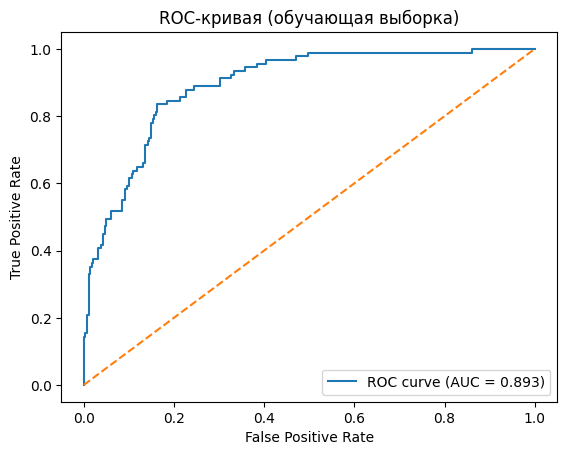

In [14]:
print("Метрики на обучающей выборке\n")

print("Точность:", accuracy_score(y_train, y_train_pred), '\n')

cm = confusion_matrix(y_train, y_train_pred)
print("Матрица ошибок:")
print(cm)

print("\nРасшифровка:")
print(f"TN (True Negative)  — правильно предсказали 0: {cm[0,0]}")
print(f"FP (False Positive) — предсказали 1, но на самом деле 0: {cm[0,1]}")
print(f"FN (False Negative) — предсказали 0, но на самом деле 1: {cm[1,0]}")
print(f"TP (True Positive)  — правильно предсказали 1: {cm[1,1]}")

print("\nClassification Report:\n", classification_report(y_train, y_train_pred))

# ROC-AUC
y_proba_train = modelML.predict_proba(X_train)[:, 1]
roc_auc_train = roc_auc_score(y_train, y_proba_train)
print(f"ROC-AUC: {roc_auc_train:.3f}")

# ROC-кривая
fpr, tpr, thresholds = roc_curve(y_train, y_proba_train)

plt.figure()
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc_train:.3f})")
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC-кривая (обучающая выборка)")
plt.legend()
plt.show()

Метрики на валидационной выборке

Точность: 0.851063829787234 

Матрица ошибок:
[[64  2]
 [12 16]]

Расшифровка:
TN (True Negative)  — правильно предсказали 0: 64
FP (False Positive) — предсказали 1, но на самом деле 0: 2
FN (False Negative) — предсказали 0, но на самом деле 1: 12
TP (True Positive)  — правильно предсказали 1: 16

Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.97      0.90        66
           1       0.89      0.57      0.70        28

    accuracy                           0.85        94
   macro avg       0.87      0.77      0.80        94
weighted avg       0.86      0.85      0.84        94

ROC-AUC: 0.925


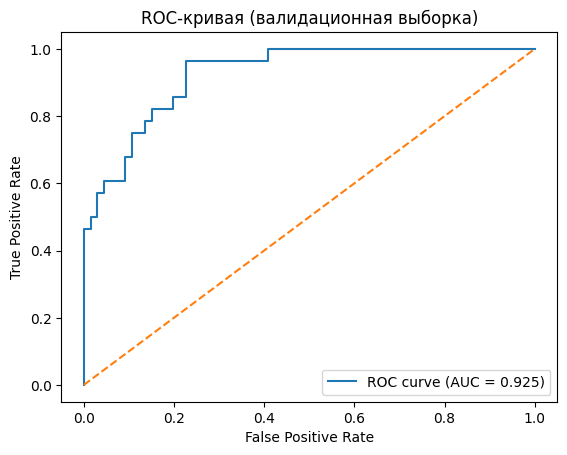

In [15]:
y_val_pred = modelML.predict(X_val)

print("Метрики на валидационной выборке\n")

print("Точность:", accuracy_score(y_val, y_val_pred), '\n')

cm = confusion_matrix(y_val, y_val_pred)
print("Матрица ошибок:")
print(cm)

print("\nРасшифровка:")
print(f"TN (True Negative)  — правильно предсказали 0: {cm[0,0]}")
print(f"FP (False Positive) — предсказали 1, но на самом деле 0: {cm[0,1]}")
print(f"FN (False Negative) — предсказали 0, но на самом деле 1: {cm[1,0]}")
print(f"TP (True Positive)  — правильно предсказали 1: {cm[1,1]}")

print("\nClassification Report:\n", classification_report(y_val, y_val_pred))

# ROC-AUC
y_val_proba = modelML.predict_proba(X_val)[:, 1]
roc_auc_val = roc_auc_score(y_val, y_val_proba)
print(f"ROC-AUC: {roc_auc_val:.3f}")

# ROC-кривая
fpr, tpr, thresholds = roc_curve(y_val, y_val_proba)

plt.figure()
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc_val:.3f})")
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC-кривая (валидационная выборка)")
plt.legend()
plt.show()

3. Оцените статистическую значимость регрессионных коэффициентов. Подробно интерпретируйте особенности взаимосвязи между каждым из предикторов и зависимой переменной.

# Оценка статистической значимости

1) **loc**: Предиктор статистически значим ($p < 0.001$). Коэффициент положительный, OR = 1.117. Это означает, что при снижении ощущения контроля над ситуацией на 1 балл, шансы на выгорание увеличиваются на 11.7%. Это один из ключевых факторов риска.

2) **cope**: Предиктор статистически значим ($p < 0.001$). Коэффициент 0.142 является самым высоким в модели, OR = 1.153. Снижение способности справляться со сложностями на 1 балл повышает шансы на выгорание на 15.3%. Это самый сильный фактор в данной модели.

3) **teaching**: Предиктор значим ($p < 0.001$), но имеет отрицательный коэффициент (-0.112), OR = 0.894. Это интересный результат: при росте показателя на 1 единицу, шансы на выгорание снижаются на 10.6% ($1 - 0.894 = 0.106$). Преподавание в данной выборке выступает «защитным» фактором.

4) **pastoral**: Предиктор значим ($p = 0.001$), OR = 1.046. Рост административной и социальной нагрузки в виде помощи коллегам увеличивает шансы на выгорание на 4.6% на каждый балл нагрузки.

5) **research**: Предиктор статистически незначим ($p = 0.062 > 0.05$). Мы не можем утверждать, что научная деятельность влияет на выгорание в данной группе сотрудников, поэтому данный фактор был исключён при оптимизации модели.

4. Проведите кросс-валидацию модели и опишите полученные результаты.

In [17]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Считаем точность (accuracy) на каждом этапе
cv_scores = cross_val_score(modelML, X_train, y_train, cv=kf)

print(f"Результаты точности по фолдам: {cv_scores}")
print(f"Средняя точность: {cv_scores.mean():.3f}")
print(f"Разброс (станд. отклонение): {cv_scores.std():.3f}")

Результаты точности по фолдам: [0.81333333 0.76       0.85333333 0.82432432 0.7972973 ]
Средняя точность: 0.810
Разброс (станд. отклонение): 0.031


# Вывод по кросс-валидации
Модель была протестирована на пяти различных подвыборках данных. Средний показатель точности составил 81%, при этом отклонение между проверками составило ~3%.

Это говорит о том, что модель устойчива: она показывает одинаково высокий результат на разных группах сотрудников.

5. Сформулируйте общие содержательные выводы по результатам регрессионного анализа данных (общие содержательные выводы - это не копирование того, что вы писали в предыдущих пунктах). Какие результаты анализа данных для вас оказались очевидными, а какие неожиданными?

# Полученные результаты
В данном домашнем задании мы изучили данные 467 сотрудников и попытались понять, какие факторы превращают любимую работу в тяжелое бремя. Мы построили математическую модель, которая с точностью 81-85% предсказывает, столкнется ли человек с выгоранием.





Мы проверяли три основные идеи:

1) Влияет ли специфика академической работы (преподавание, наука, помощь коллегам) на риск выгорания?
    * Гипотеза (H1): Подтверждена частично.
2) Насколько сильно внутреннее состояние человека и его умение справляться с трудностями защищают от выгорания?
    * Гипотеза (H1): Подтверждена.
3) Есть ли группы риска среди сотрудников разного пола или с разным уровнем образования?
    * Гипотеза (H0): На данной выборке нет оснований считать её верной.


Модель продемонстрировала надежные повторяемые результаты. Показатель AUC = 0.925 говорит о том, что она неплохо разделяет сотрудников по выгоранию. Основными предикторами выгорания стали `loc` и `cope`, также были подтверждены результаты по `pastoral` - чем больше мы тратим времени на чужие проблемы, тем выше наш шанс выгорания.

Неожиданными являются:
1) Преподавание как защита от выгорания. Люди, которые больше преподают, выгорают на 10% меньше.
2) Стресс от исследований практически не влияет на выгорание.

Комментарии к заданию и принципам его оценивания:

 - Все пункты задания должны сопровождаться выполненным фрагментом кода. В этом задании будет проверяться корректность работы кода, то есть будут последовательно запущены ячейки, чтобы убедиться, что код не выдаст ошибку в какой-то момент. Перед отправкой работы на проверку рекомендуется "прогнать" код.
 - Если Вы получили результаты в виде статистических показателей, таблиц или графиков, при этом никак их не прокомментировали и не сформулировали содержательные выводы на их основе, то работа оценивается в 0 баллов, в этом случае анализ данных не проведён.
 - Если Вы полностью выполнили это задание, то получаете за него 8 баллов (отлично). Для получения более высокой оценки нужно выйти за рамки предложенного задания. В случае с текущим заданием это может быть дополнительное самостоятельное изучение инструментов регрессионного анализа и их применение, или развернутое и глубокое исследование имеющихся данных на основе использования пройденных на занятиях методов.
 - В этом задании 5 пунктов. Первый весит 15%, второй - 20%, третий - 30%, четвертый - 20%, пятый - 15%.

### Этот файл нужно сохранить как Jupyter Notebook (.ipynb) и отправить на amelikyan@hse.ru до 23:55 27 апреля.